In [138]:
import numpy as np
import matplotlib.pyplot as plt
import os
import argparse
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Circle
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D

def split_trajectory_by_episode(full_trajectory):
    """
    Divide um array de trajetória contínuo em uma lista de episódios individuais.
    Usa a coluna de 'step' (coluna 0) para identificar o início de um novo episódio.
    """
    start_indices = np.where(full_trajectory[:, 0] == 0)[0]
    if len(start_indices) == 0:
        return [full_trajectory]
    episodes = []
    for i in range(len(start_indices)):
        start = start_indices[i]
        end = start_indices[i+1] if (i + 1) < len(start_indices) else len(full_trajectory)
        episodes.append(full_trajectory[start:end])
    return episodes

def load_maze_from_file(filepath):
    """Lê um arquivo de texto e o converte em uma matriz binária do labirinto."""
    char_map = {'1': 1, '0': 0}
    with open(filepath, 'r') as f:
        lines = [line.replace(',', '').rstrip('\n') for line in f]
    binary_maze = [[char_map.get(char, 0) for char in line] for line in lines]
    return np.array(binary_maze, dtype=int)

def plot_static_trajectory(model_path, episode_number):
    """
    Carrega os dados, seleciona o episódio pelo NÚMERO e plota a trajetória
    como uma linha contínua com segmentos coloridos por estado.
    """
    # --- Carregar Dados ---
    trajectory_file = os.path.join('../data/models/', model_path, 'trajectory.txt')
    maze_file = '../data/maze/maze_3.txt'

    if not os.path.exists(trajectory_file):
        print(f"ERRO: Não foi encontrado 'trajectory.txt' em '{model_path}'")
        return
    if not os.path.exists(maze_file):
        print(f"AVISO: Não foi encontrado 'maze.txt' em '{model_path}'. O labirinto não será desenhado.")
        maze_grid = None
    else:
        maze_grid = load_maze_from_file(maze_file)

    full_trajectory = np.loadtxt(trajectory_file, delimiter=',')
    
    # --- Selecionar o Episódio ---
    episodes = split_trajectory_by_episode(full_trajectory)
    if not episodes:
        print("Nenhum episódio encontrado no arquivo de trajetória.")
        return

    try:
        episode_idx = int(episode_number) - 1
        if episode_idx == -2: # Mapeia o -1 do usuário para o último índice
            episode_idx = len(episodes) - 1
        
        if episode_idx < 0 or episode_idx >= len(episodes):
            print(f"ERRO: Episódio {episode_idx + 1} inválido. O arquivo contém {len(episodes)} episódios (de 1 a {len(episodes)}).")
            return
            
        trajectory = episodes[episode_idx]
        title_suffix = f" (Episódio {episode_idx + 1})"
    except ValueError:
        print(f"ERRO: O número do episódio deve ser um inteiro. Recebido: '{episode_number}'")
        return

    # --- Extrair Dados do Episódio Selecionado ---
    # Colunas: 0:step, 1:state, 2:reward, 3:pos_x, 4:pos_y, 5:target_x, 6:target_y
    states = trajectory[:, 1]
    positions_x = trajectory[:, 4]
    positions_y = trajectory[:, 5]
    target_pos = trajectory[0, 6:8]

    # --- Plotagem ---
    fig, ax = plt.subplots(figsize=(12, 12))
    
    if maze_grid is not None:
        ax.imshow(maze_grid, cmap='Greys', origin='lower', extent=[0, 100, 0, 100], alpha=0.8)

    # --- Lógica da LineCollection para Trajetória Colorida ---
    points = np.array([positions_x, positions_y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    colors = ['royalblue' if s == 0 else 'crimson' for s in states[:-1]]
    
    lc = LineCollection(segments, colors=colors, linewidths=2.0)
    ax.add_collection(lc)

    # --- Marcar Pontos Importantes ---
    ax.plot(positions_x[0], positions_y[0], 'o', color='lime', markersize=10, markeredgecolor='black', label='Início')
    ax.plot(positions_x[-1], positions_y[-1], 'X', color='magenta', markersize=12, markeredgecolor='black', label='Fim')
    ax.plot(target_pos[0], target_pos[1], '*', color='gold', markersize=20, markeredgecolor='black', label='Alvo')

    # --- Legenda e Configurações Finais ---
    legend_elements = [
        Line2D([0], [0], color='royalblue', lw=2, label='Estado Passivo'),
        Line2D([0], [0], color='crimson', lw=2, label='Estado Ativo')
    ]
    # Combina as legendas dos pontos com as das linhas
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles + legend_elements, fontsize=12)

    ax.set_title(f'Trajetória do Agente no Labirinto{title_suffix}\n(Modelo: {os.path.basename(model_path)})', fontsize=16)
    ax.set_xlabel('Posição X', fontsize=12)
    ax.set_ylabel('Posição Y', fontsize=12)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_aspect('equal', adjustable='box')
    plt.grid(False)
    plt.show()

In [139]:
sorted(os.listdir('../data/models/maze_P=50'))

['2026-04-25_05-08-02.780712__0']

In [140]:
#animate_trajectory('maze_P=100/2026-04-25_00-33-30.960072__0', True)

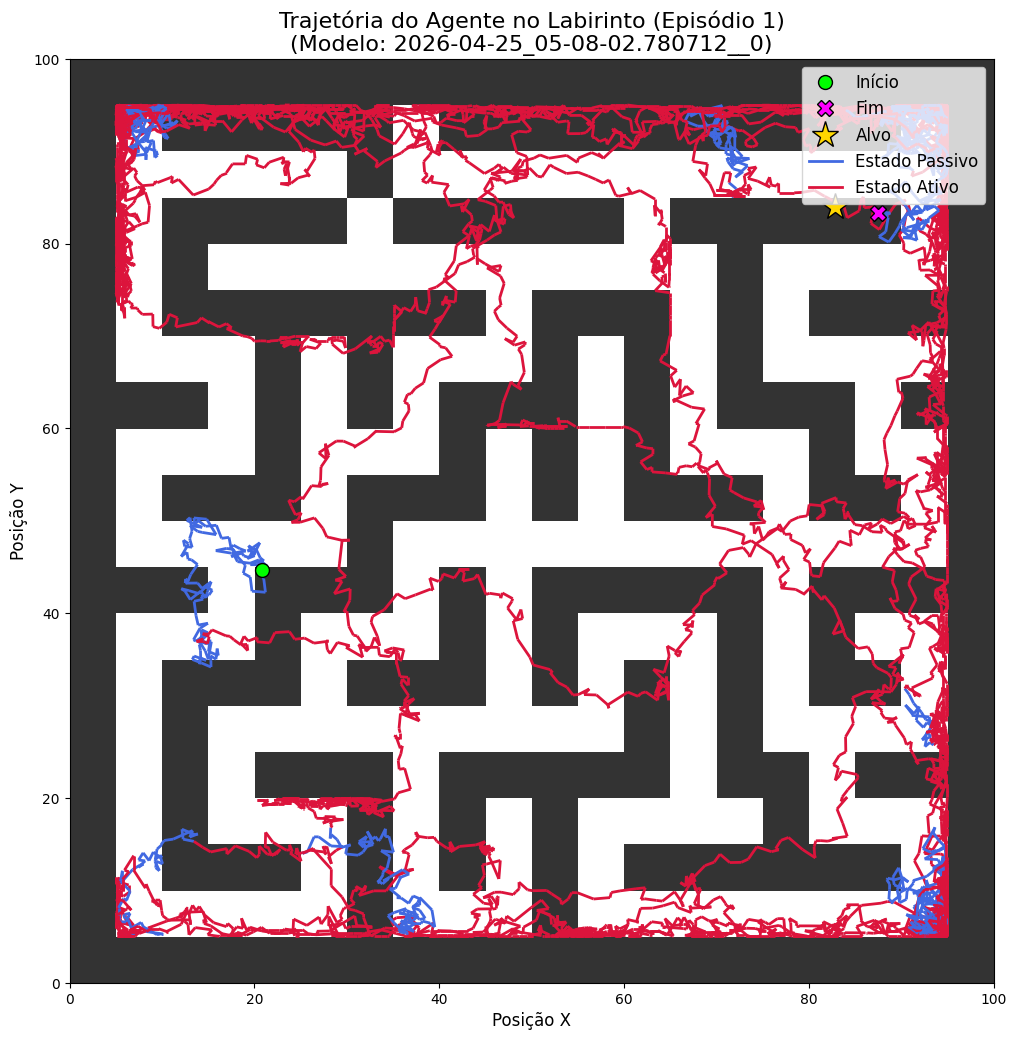

In [141]:
plot_static_trajectory('maze_P=50/2026-04-25_05-08-02.780712__0', 1)